# Network modeling

model the network and derive travel time matrix

In [61]:
import networkx as nx
import numpy as np
import pandas as pd

# Create a directed graph
G = nx.DiGraph()

# Add edges with weights based on the image
edges = [
    (0, 1, 22), (0, 2, 20),
    (1, 3, 20), (1, 4, 20), (1, 5, 22),
    (2, 5, 20), (2, 6, 20),
    (3, 7, 20),
    (4, 7, 22), (4, 8, 20),
    (5, 8, 20), (5, 9, 22),
    (6, 9, 20),
    (7, 10, 20), (7, 11, 24),
    (8, 11, 20),
    (9, 11, 20),
    (10, 12, 10),
    (11, 12, 10)
]
G.add_weighted_edges_from(edges)

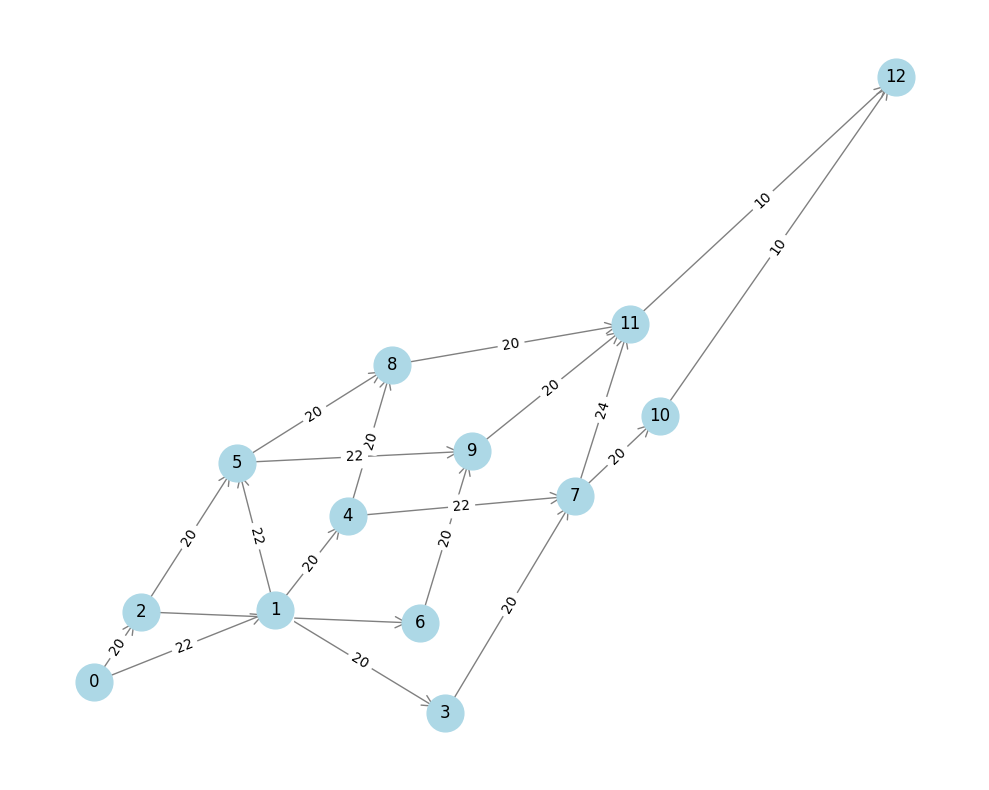

In [62]:
import matplotlib.pyplot as plt
def plot_network(G):
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G,seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_network(G)


In [63]:
22+20+20+20+10

92

In [64]:
# Compute distance matrix using Floyd-Warshall algorithm
distance_matrix = nx.floyd_warshall_numpy(G, weight='weight')

# Convert to DataFrame for readability
nodes = list(G.nodes())
df = pd.DataFrame(distance_matrix, index=nodes, columns=nodes)

print(df)

     0     1     2     3     4     5     6     7     8     9     10    11  \
0   0.0  22.0  20.0  42.0  42.0  40.0  40.0  62.0  60.0  60.0  82.0  80.0   
1   inf   0.0   inf  20.0  20.0  22.0   inf  40.0  40.0  44.0  60.0  60.0   
2   inf   inf   0.0   inf   inf  20.0  20.0   inf  40.0  40.0   inf  60.0   
3   inf   inf   inf   0.0   inf   inf   inf  20.0   inf   inf  40.0  44.0   
4   inf   inf   inf   inf   0.0   inf   inf  22.0  20.0   inf  42.0  40.0   
5   inf   inf   inf   inf   inf   0.0   inf   inf  20.0  22.0   inf  40.0   
6   inf   inf   inf   inf   inf   inf   0.0   inf   inf  20.0   inf  40.0   
7   inf   inf   inf   inf   inf   inf   inf   0.0   inf   inf  20.0  24.0   
8   inf   inf   inf   inf   inf   inf   inf   inf   0.0   inf   inf  20.0   
9   inf   inf   inf   inf   inf   inf   inf   inf   inf   0.0   inf  20.0   
10  inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   0.0   inf   
11  inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   inf   0.0   

In [65]:
nx.shortest_path(G, 0, 12)

[0, 1, 3, 7, 10, 12]

In [66]:
sp = dict(nx.all_pairs_shortest_path(G))

In [67]:
sp[0]

{0: [0],
 1: [0, 1],
 2: [0, 2],
 3: [0, 1, 3],
 4: [0, 1, 4],
 5: [0, 1, 5],
 6: [0, 2, 6],
 7: [0, 1, 3, 7],
 8: [0, 1, 4, 8],
 9: [0, 1, 5, 9],
 10: [0, 1, 3, 7, 10],
 11: [0, 1, 3, 7, 11],
 12: [0, 1, 3, 7, 10, 12]}

In [68]:
sp[0][12]

[0, 1, 3, 7, 10, 12]

In [69]:
total_weight = sum(G.edges[node, sp[0][12][i+1]]['weight'] for i, node in enumerate(sp[0][12][:-1]))
print("Total weight of all edges:", total_weight)

Total weight of all edges: 92


that is not the shortest path ...???!!!


## get all possible path and their corresponding weights

In [70]:

def path_weight_sum(G, path):
    return sum(G[u][v]['weight'] for u, v in zip(path[:-1], path[1:]))
def path_weight_vec(G, path):
    return [G[u][v]['weight'] for u, v in zip(path[:-1], path[1:])]

start = 0
target = 12

# Get all simple paths
paths = list(nx.all_simple_paths(G, source=start, target=target))
#print("All possible paths:")
#for p in paths:
#    print(p)
weighted_paths = [(p, path_weight_sum(G, p)) for p in paths]
print("\nAll possible paths with weights:")
w_vec = []
for p, w in weighted_paths:
    print(f"Path: {p}, Weight: {w}")
    w_vec.append(w)
print('shortest path(s): ')
min_weight = np.min(w_vec)
min_paths = [p for p, w in weighted_paths if w == min_weight]
min_paths


All possible paths with weights:
Path: [0, 1, 3, 7, 10, 12], Weight: 92
Path: [0, 1, 3, 7, 11, 12], Weight: 96
Path: [0, 1, 4, 7, 10, 12], Weight: 94
Path: [0, 1, 4, 7, 11, 12], Weight: 98
Path: [0, 1, 4, 8, 11, 12], Weight: 92
Path: [0, 1, 5, 8, 11, 12], Weight: 94
Path: [0, 1, 5, 9, 11, 12], Weight: 96
Path: [0, 2, 5, 8, 11, 12], Weight: 90
Path: [0, 2, 5, 9, 11, 12], Weight: 92
Path: [0, 2, 6, 9, 11, 12], Weight: 90
shortest path(s): 


[[0, 2, 5, 8, 11, 12], [0, 2, 6, 9, 11, 12]]

In [71]:
# now add some variance to the edge weights

relative_variances = False

N = 1000 # number of samples per path


if relative_variances:
    std_vec = np.array([0.1,0.2,0.3,0.4,0.5,0.8])
else:
    std_vec = np.array([0.1,0.2,0.3,0.4,0.5,0.8])*15
w=np.zeros((len(std_vec),len(paths),N))

for kk in range(len(std_vec)):#std in std_vec:
    std=std_vec[kk]
    '# Add noise to each edge weight of each possible path'
    for jj in range(len(paths)):#p in paths:
        path_weights = path_weight_vec(G, paths[jj])
        for nn in range(N): # number of samples per path
            path_weights_variance = np.zeros(len(path_weights))
            #std_sample = np.random.normal(0, std)
            for ii in range(len(path_weights)):
                # while running through the path, the weights are changing according a normal distribution
                std_sample = np.random.normal(0, std)
                if relative_variances:
                    path_weights_variance[ii] = path_weights[ii] + (path_weights[ii]*std_sample)
                else:
                    path_weights_variance[ii] = path_weights[ii] + std_sample
            w[kk,jj,nn] = np.sum(path_weights_variance)


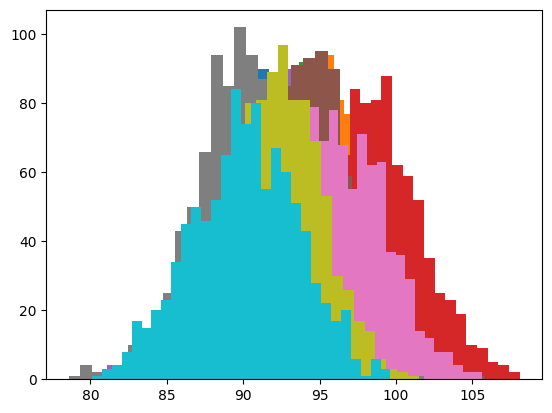

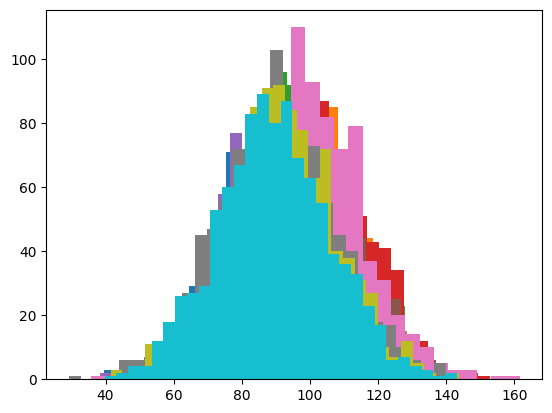

In [72]:
for ii in range(len(paths)):
    plt.hist(w[0][ii][:], bins=30);
plt.figure()
for ii in range(len(paths)):
    plt.hist(w[4][ii][:], bins=30);


In [73]:
for ii in range(len(paths)):
    prob = np.mean(w[5][ii][:] <= 86)
    print(f"Path {ii}: Probability travel time <= 86 minutes: {prob:.4f}")

Path 0: Probability travel time <= 86 minutes: 0.3990
Path 1: Probability travel time <= 86 minutes: 0.3590
Path 2: Probability travel time <= 86 minutes: 0.3830
Path 3: Probability travel time <= 86 minutes: 0.2920
Path 4: Probability travel time <= 86 minutes: 0.4000
Path 5: Probability travel time <= 86 minutes: 0.3860
Path 6: Probability travel time <= 86 minutes: 0.3510
Path 7: Probability travel time <= 86 minutes: 0.4390
Path 8: Probability travel time <= 86 minutes: 0.4290
Path 9: Probability travel time <= 86 minutes: 0.4570


In [74]:
import plotly.graph_objects as go

# Assuming w is defined from previous cells
means = np.mean(w, axis=2)
stds = np.std(w, axis=2)

fig = go.Figure()
colors_rgb = [
    'rgb(0,0,255)',  # blue
    'rgb(255,0,0)',  # red
    'rgb(0,128,0)',  # green
    'rgb(255,165,0)',  # orange
    'rgb(128,0,128)'  # purple
]
for j in range(len(paths)):
    color = colors_rgb[j % len(colors_rgb)]
    fillcolor = color.replace('rgb', 'rgba').replace(')', ',0.2)')
    legendgroup = f'Path {j}'
    # Add upper bound
    fig.add_trace(go.Scatter(
        x=std_vec,
        y=means[:, j] + stds[:, j],
        mode='lines',
        line=dict(width=0),
        showlegend=False,
        legendgroup=legendgroup
    ))
    # Add lower bound with fill
    fig.add_trace(go.Scatter(
        x=std_vec,
        y=means[:, j] - stds[:, j],
        mode='lines',
        fill='tonexty',
        fillcolor=fillcolor,
        line=dict(width=0),
        showlegend=False,
        legendgroup=legendgroup
    ))
    # Add main line
    fig.add_trace(go.Scatter(
        x=std_vec,
        y=means[:, j],
        error_y=dict(type='data', array=stds[:, j]),
        mode='lines+markers',
        line=dict(color=color),
        name=f'Path {j}',
        legendgroup=legendgroup
    ))
fig.update_layout(
    title='Mean Weight with Std Dev for Each Path Across Std Levels',
    xaxis_title='Std Level',
    yaxis_title='Mean Weight'
)
fig.show()

## Conclution

so, even if we assume normal distributed weights, the mean is still the same, thus path 9, i.e. using node 2 is fastest!
All above is still a single shot optimization assuming all weights are known upfront.

## Make a Policy

setting:
- problem/solution evolves over time, in each "timestep" we reach the next node
- at begin of each timestep, all weights of the graph are updated from a normal distribution
    - with fixed absolute variance/deviation
    - or with a relative variance/standard deviation
- a seach algorithm must find the shortes path from the current node, given the new updated weight

In [75]:
import copy

def get_shortest_path(G, start, target):
    paths = list(nx.all_simple_paths(G, source=start, target=target))
    path_sum_weights = [path_weight_sum(G, p) for p in paths]
    idx = np.argmin(path_sum_weights)
    return paths[idx], path_sum_weights[idx]

def update_network(G,std,mode):
    G_mod = copy.deepcopy(G)
    if mode == 'relative':
        for u, v in G.edges():
            base_weight = G[u][v]['weight']
            std_sample = base_weight * np.random.normal(0, std)
            G_mod[u][v]['weight'] = np.round(base_weight + std_sample,2)
    elif mode == 'absolute':
        for u, v in G.edges():
            base_weight = G[u][v]['weight']
            std_sample = np.random.normal(0, std)
            G_mod[u][v]['weight'] = np.round(base_weight + std_sample,2)
    else:
        raise ValueError("Mode must be 'relative' or 'absolute'")

    return G_mod

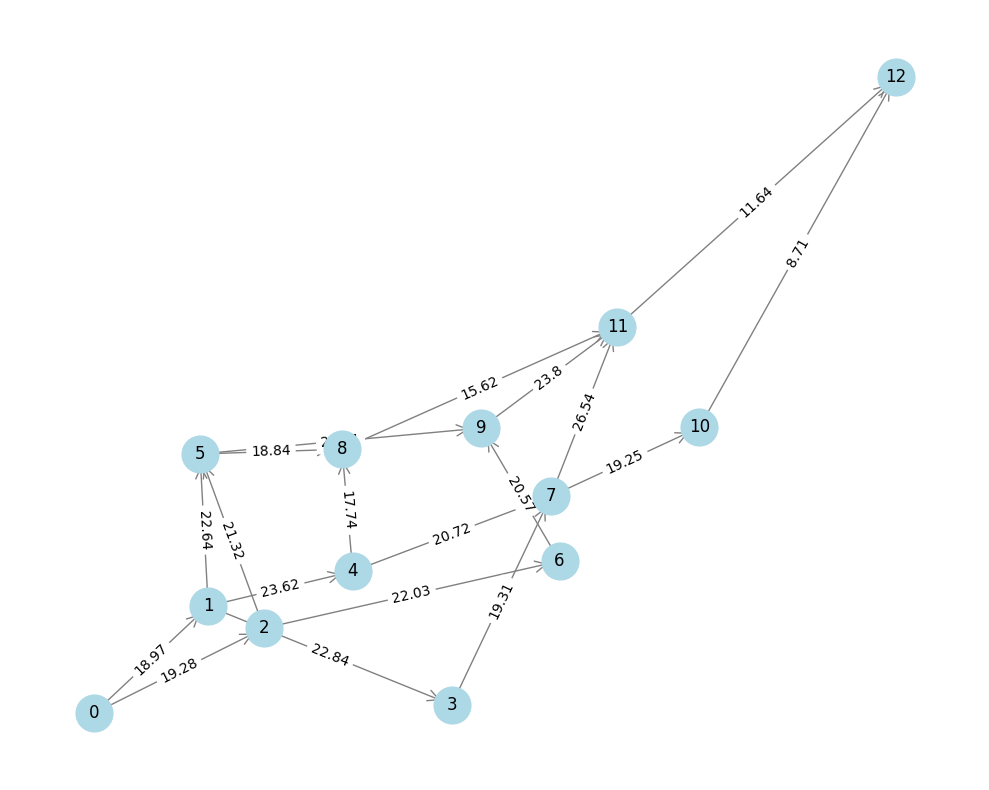

In [76]:
# test is modifiying the graph is working properly
G_mod=update_network(G,0.1,'relative')
plot_network(G_mod)

In [77]:
# test the shortes path function
G_mod=update_network(G,0.1,'relative')
start=0
target=12
p,w=get_shortest_path(G_mod, start, target)
print(p)
print(w)

[0, 2, 6, 9, 11, 12]
86.03


## Simulate the policy

the "policy" itself is kind of "Direct Lookahead" policy, that determined the shortest path using the given (updated) weights

In [85]:
std_mode = 'relative'
#std_mode = 'absolute'
if std_mode == 'relative':
    std = 0.15
elif std_mode == 'absolute':
    std = 5

N = 10000 # number of samples per path
paths_taken = []
travel_times = []

for ii in range(N):
    start=0
    target=12

    path = []
    path.append(start)
    travel_time=0
    target_reached=False

    while target_reached == False:
        # update the network weights (e.g based on latest traffic information)
        G_mod=update_network(G,std,std_mode)
        p,w=get_shortest_path(G_mod, start, target)
        # travel to the first node in the current shortest path
        path.append(p[1])
        travel_time += G_mod[start][p[1]]['weight']
        # this node now gets the start node for the next timestep
        start = p[1]
        if start == target:
            target_reached = True
    paths_taken.append(path)
    travel_times.append(travel_time)


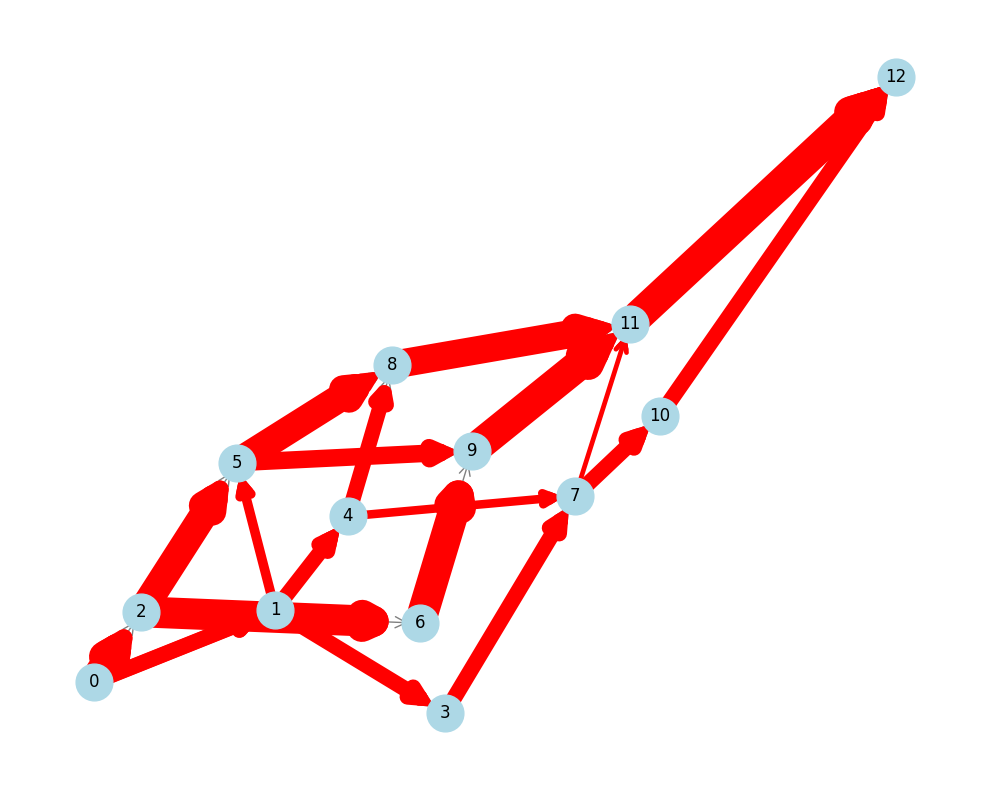

Total simulations: 10000
Unique paths taken: 10
Path [0, 2, 6, 9, 11, 12]: taken 2235 times, avg travel time: 87.71, prob <=86 min: 0.3826
Path [0, 2, 5, 8, 11, 12]: taken 2024 times, avg travel time: 87.30, prob <=86 min: 0.4209
Path [0, 2, 5, 9, 11, 12]: taken 1257 times, avg travel time: 88.10, prob <=86 min: 0.3588
Path [0, 1, 3, 7, 10, 12]: taken 1131 times, avg travel time: 88.43, prob <=86 min: 0.3360
Path [0, 1, 4, 8, 11, 12]: taken 1091 times, avg travel time: 88.47, prob <=86 min: 0.3437
Path [0, 1, 5, 8, 11, 12]: taken 689 times, avg travel time: 89.20, prob <=86 min: 0.3106
Path [0, 1, 4, 7, 10, 12]: taken 616 times, avg travel time: 88.73, prob <=86 min: 0.3247
Path [0, 1, 5, 9, 11, 12]: taken 448 times, avg travel time: 90.18, prob <=86 min: 0.2344
Path [0, 1, 3, 7, 11, 12]: taken 340 times, avg travel time: 89.58, prob <=86 min: 0.2941
Path [0, 1, 4, 7, 11, 12]: taken 169 times, avg travel time: 89.69, prob <=86 min: 0.2426


In [86]:
from collections import Counter

# Count path frequencies
path_counts = Counter(tuple(p) for p in paths_taken)

# Plot the network with path frequencies
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')
# Draw base edges thin
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1)
# Draw paths with thickness based on frequency
for path_tuple, count in sorted(path_counts.items(), key=lambda x: x[1]):
    path = list(path_tuple)
    edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    width = count / 100.0  # adjust factor for visibility
    nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle='->', arrowsize=20, edge_color='red', width=width)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print some statistics
print(f"Total simulations: {N}")
print(f"Unique paths taken: {len(path_counts)}")
for path, count in path_counts.most_common(10):
    path_list = list(path)
    times = [t for p, t in zip(paths_taken, travel_times) if p == path_list]
    avg_time = np.mean(times)
    prob_under_86 = np.mean([t <= 86 for t in times])
    print(f"Path {path_list}: taken {count} times, avg travel time: {avg_time:.2f}, prob <=86 min: {prob_under_86:.4f}")